<a href="https://colab.research.google.com/github/akfreeman72/Hotel-Demand-Forecasting-Project/blob/main/44project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install statsforecast mlforecast neuralforecast lightgbm utilsforecast -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

df = pd.read_parquet("sample_hotels-1.parquet")

print(df.head())

     unique_id         ds holiday_flag target_day target_month  target_year  \
1430   hotel_0 2022-01-01           no        Sat          Jan         2022   
1431   hotel_0 2022-01-02           no        Sun          Jan         2022   
1432   hotel_0 2022-01-03           no        Mon          Jan         2022   
1433   hotel_0 2022-01-04           no        Tue          Jan         2022   
1434   hotel_0 2022-01-05           no        Wed          Jan         2022   

     location_type              hotel_type         y     otb_1  ...    otb_51  \
1430   NonSuburban  Resorts & Destinations  0.975309  0.679012  ...  0.197531   
1431   NonSuburban  Resorts & Destinations  0.493827  0.308642  ...  0.074074   
1432   NonSuburban  Resorts & Destinations  0.456790  0.358025  ...  0.024691   
1433   NonSuburban  Resorts & Destinations  0.592593  0.419753  ...  0.074074   
1434   NonSuburban  Resorts & Destinations  0.530864  0.407407  ...  0.074074   

        otb_52    otb_53    otb_54    

In [ ]:
import pandas as pd

df = pd.read_parquet("sample_hotels-1.parquet")
print(df.head())
print(df.columns)
print(df.shape)

In [ ]:
print(df.columns)
df.head()

Index(['unique_id', 'ds', 'holiday_flag', 'target_day', 'target_month',
       'target_year', 'location_type', 'hotel_type', 'y', 'otb_1', 'otb_2',
       'otb_3', 'otb_4', 'otb_5', 'otb_6', 'otb_7', 'otb_8', 'otb_9', 'otb_10',
       'otb_11', 'otb_12', 'otb_13', 'otb_14', 'otb_15', 'otb_16', 'otb_17',
       'otb_18', 'otb_19', 'otb_20', 'otb_21', 'otb_22', 'otb_23', 'otb_24',
       'otb_25', 'otb_26', 'otb_27', 'otb_28', 'otb_29', 'otb_30', 'otb_31',
       'otb_32', 'otb_33', 'otb_34', 'otb_35', 'otb_36', 'otb_37', 'otb_38',
       'otb_39', 'otb_40', 'otb_41', 'otb_42', 'otb_43', 'otb_44', 'otb_45',
       'otb_46', 'otb_47', 'otb_48', 'otb_49', 'otb_50', 'otb_51', 'otb_52',
       'otb_53', 'otb_54', 'otb_55', 'otb_56', 'otb_57', 'otb_58', 'otb_59',
       'otb_60'],
      dtype='object')


,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


In [ ]:
df = df[['unique_id', 'ds', 'y']].copy()
df = df.sort_values(['unique_id', 'ds'])

print(df.head())

     unique_id         ds         y
1430   hotel_0 2022-01-01  0.975309
1431   hotel_0 2022-01-02  0.493827
1432   hotel_0 2022-01-03  0.456790
1433   hotel_0 2022-01-04  0.592593
1434   hotel_0 2022-01-05  0.530864


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS

sf_fast = StatsForecast(
    models=[
        Naive(),
        SeasonalNaive(season_length=7),
        AutoETS(season_length=7)
    ],
    freq='D',
    n_jobs=-1
)

cv_sf_fast = sf_fast.cross_validation(
    df=df,
    h=28,
    n_windows=5,
    step_size=28
)

cv_sf_fast.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.798058
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.592257
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.611757
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.625062
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.616607


In [ ]:
# AutoARIMA was too slow in this environment, so this model is being skipped temporarily.
# We completed Naive, SeasonalNaive, and AutoETS first.
cv_sf = cv_sf_fast.copy()

In [ ]:
cv_sf.to_csv("cross_validation_statsforecast.csv", index=False)

In [ ]:
df = df.groupby(["unique_id", "ds"], as_index=False)["y"].mean()

df = (
    df.set_index("ds")
      .groupby("unique_id")
      .resample("D")
      .asfreq()
      .drop(columns=["unique_id"])
      .reset_index()
)

df["y"] = df["y"].fillna(0)

df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(df.shape)
print(df.duplicated(subset=["unique_id", "ds"]).sum())

(10188, 3)
0


In [ ]:
cv_mf = mf.cross_validation(
    df=df,
    h=28,
    n_windows=5,
    step_size=28,
    refit=True
)

cv_mf.head()

,unique_id,ds,cutoff,y,LGBMRegressor
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.851097
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.645710
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.758823
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.818447
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.823287


In [ ]:
results = cv_sf.merge(
    cv_mf.drop(columns=["y"], errors="ignore"),
    on=["unique_id", "ds", "cutoff"],
    how="left"
)

results.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,LGBMRegressor
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.798058,0.851097
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.592257,0.645710
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.611757,0.758823
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.625062,0.818447
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.616607,0.823287


In [ ]:
results.to_csv("cross_validation_results.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd

def calculate_metrics(group):
    model_cols = [c for c in group.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
    rows = []

    for model in model_cols:
        temp = group[["y", model]].dropna()
        error = temp[model] - temp["y"]

        me = error.mean()
        mae = error.abs().mean()
        rmse = np.sqrt((error ** 2).mean())

        nonzero = temp[temp["y"] != 0]
        mape = np.nan
        if len(nonzero) > 0:
            mape = (np.abs((nonzero["y"] - nonzero[model]) / nonzero["y"]).mean()) * 100

        rows.append({
            "unique_id": group["unique_id"].iloc[0],
            "Model": model,
            "ME": me,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    return pd.DataFrame(rows)

final_metrics = (
    results
    .groupby("unique_id", group_keys=False)
    .apply(calculate_metrics)
    .reset_index(drop=True)
)

final_metrics.head()

/tmp/ipykernel_2388/643543312.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_metrics)


,unique_id,Model,ME,MAE,RMSE,MAPE
0,hotel_0,Naive,0.082011,0.194709,0.252434,34.109032
1,hotel_0,SeasonalNaive,0.029806,0.214286,0.267155,35.419121
2,hotel_0,AutoETS,-0.007384,0.184314,0.223515,29.729600
3,hotel_0,LGBMRegressor,0.032413,0.140379,0.186680,24.388673
4,hotel_105,Naive,0.053190,0.120036,0.159475,16.684634


In [ ]:
final_metrics.to_csv("metric_summary_by_series_method.csv", index=False)

In [ ]:
win_rows = []

for metric in ["MAE", "RMSE", "MAPE"]:
    metric_df = final_metrics.dropna(subset=[metric])
    winners = metric_df.loc[metric_df.groupby("unique_id")[metric].idxmin()]
    counts = winners["Model"].value_counts().reset_index()
    counts.columns = ["Model", "Wins"]
    counts["Metric"] = metric
    win_rows.append(counts)

me_df = final_metrics.copy()
me_df["abs_ME"] = me_df["ME"].abs()
me_winners = me_df.loc[me_df.groupby("unique_id")["abs_ME"].idxmin()]
me_counts = me_winners["Model"].value_counts().reset_index()
me_counts.columns = ["Model", "Wins"]
me_counts["Metric"] = "ME"
win_rows.append(me_counts)

win_counts = pd.concat(win_rows, ignore_index=True)

win_counts

,Model,Wins,Metric
0,LGBMRegressor,6,MAE
1,AutoETS,6,MAE
2,Naive,5,MAE
3,SeasonalNaive,2,MAE
4,LGBMRegressor,9,RMSE
5,AutoETS,7,RMSE
6,Naive,2,RMSE
7,SeasonalNaive,1,RMSE
8,LGBMRegressor,8,MAPE
9,AutoETS,4,MAPE


In [ ]:
win_counts.to_csv("model_win_counts.csv", index=False)

In [ ]:
# Final forecasts using the full dataset

sf_forecast = sf_fast.forecast(df=df, h=28)

mf.fit(df)
mf_forecast = mf.predict(h=28)

final_forecasts = sf_forecast.merge(
    mf_forecast,
    on=["unique_id", "ds"],
    how="left"
)

final_forecasts.head()

,unique_id,ds,Naive,SeasonalNaive,AutoETS,LGBMRegressor
0,hotel_0,2023-07-01,0.82716,0.950617,0.854200,0.895565
1,hotel_0,2023-07-02,0.82716,0.506173,0.625889,0.608831
2,hotel_0,2023-07-03,0.82716,0.580247,0.646667,0.662011
3,hotel_0,2023-07-04,0.82716,0.691358,0.683990,0.716965
4,hotel_0,2023-07-05,0.82716,0.654321,0.681233,0.758439


In [ ]:
final_forecasts.to_csv("final_test_forecasts.csv", index=False)

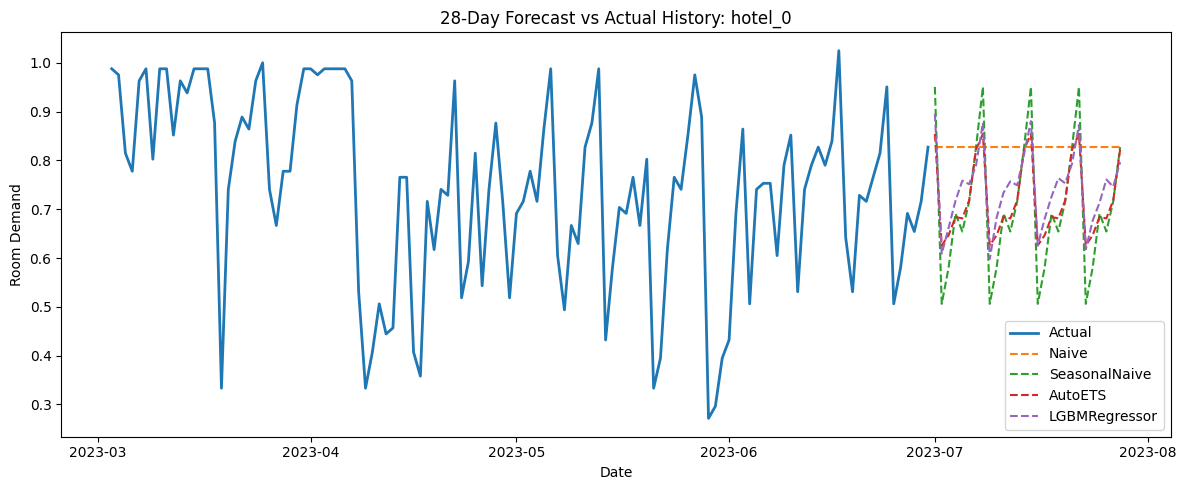

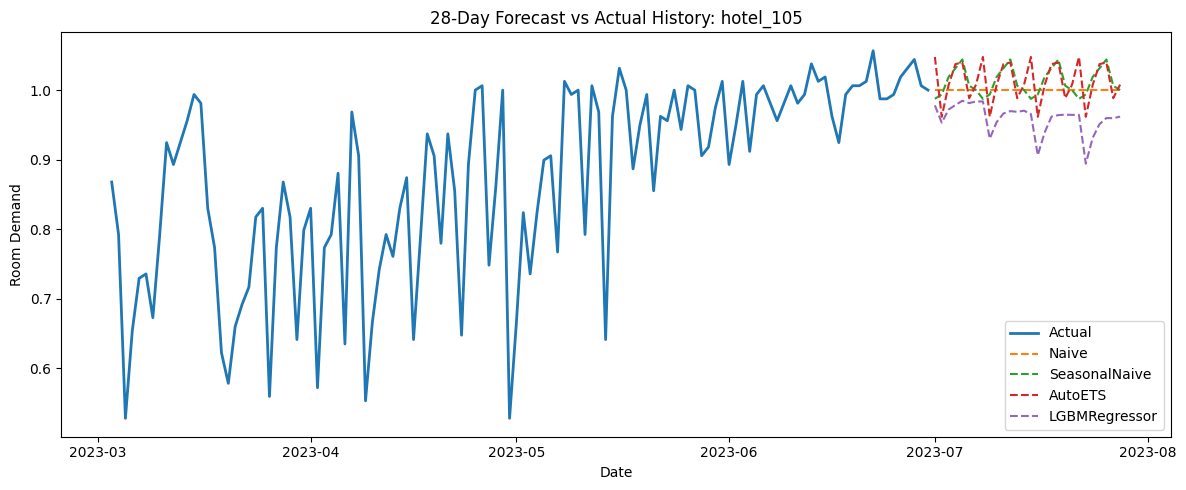

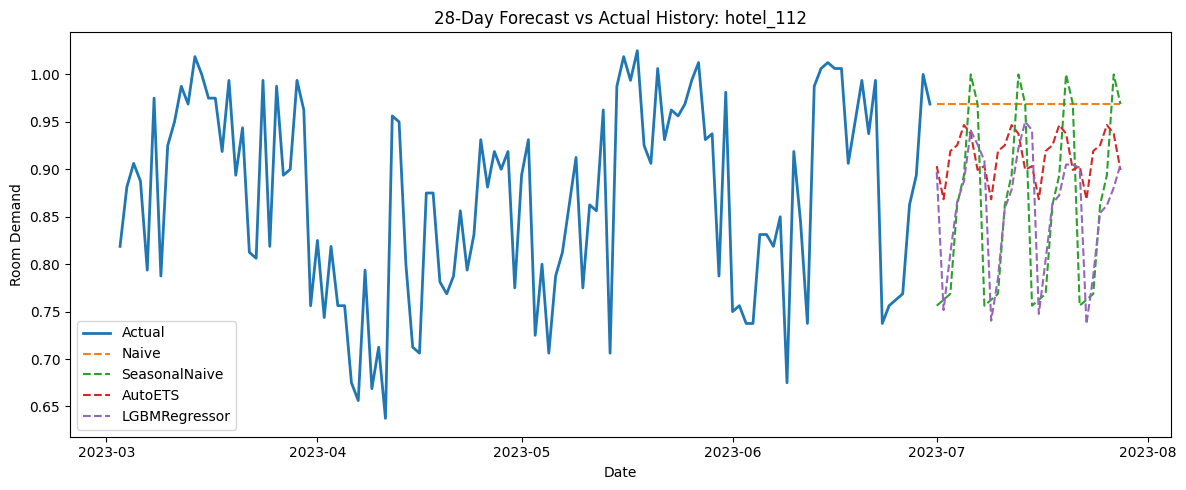

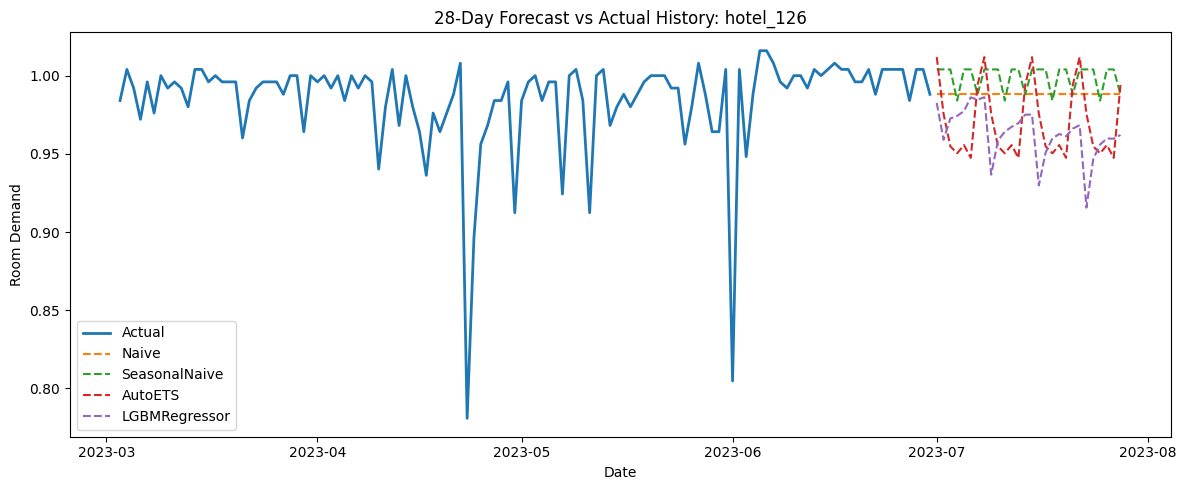

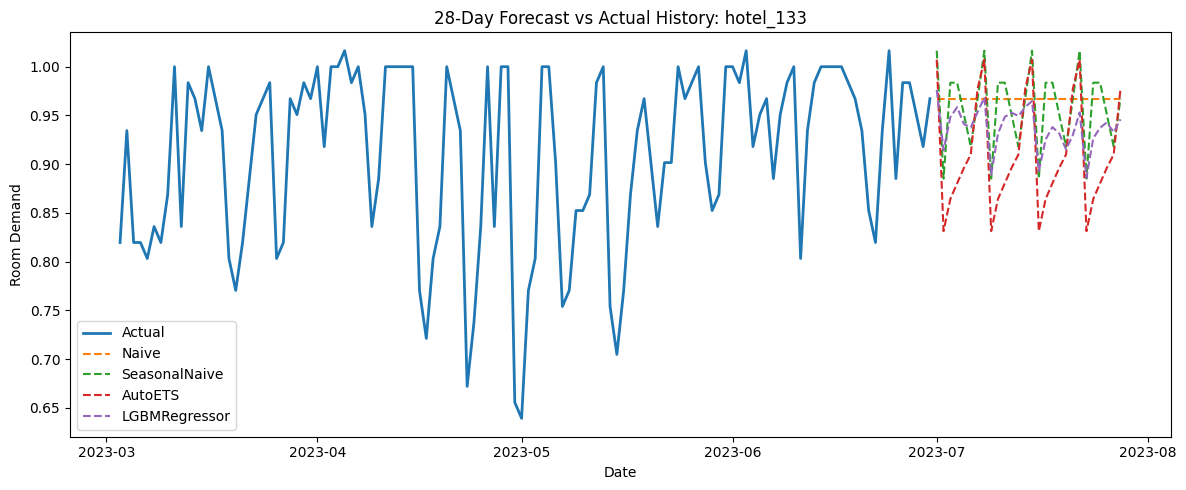

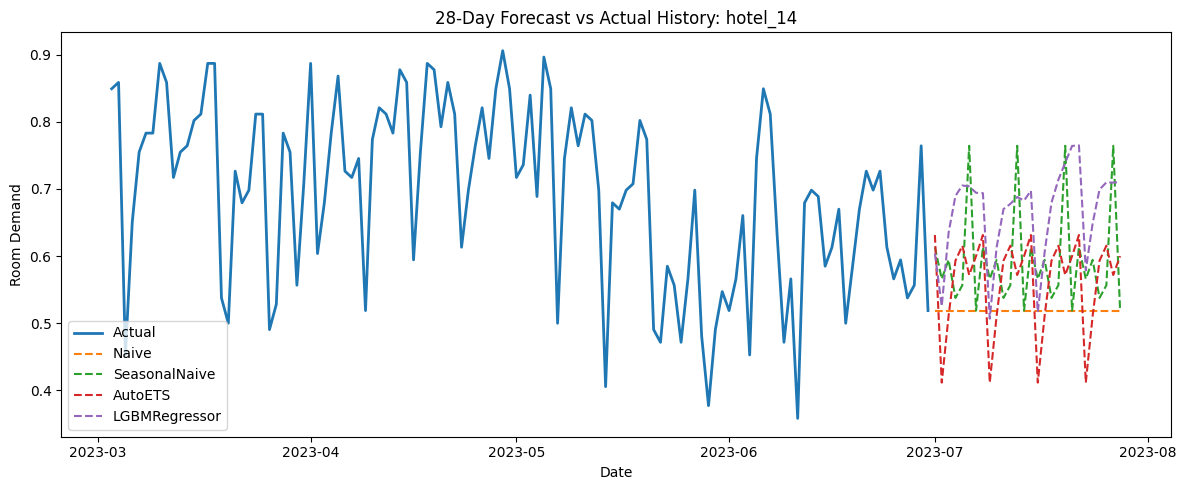

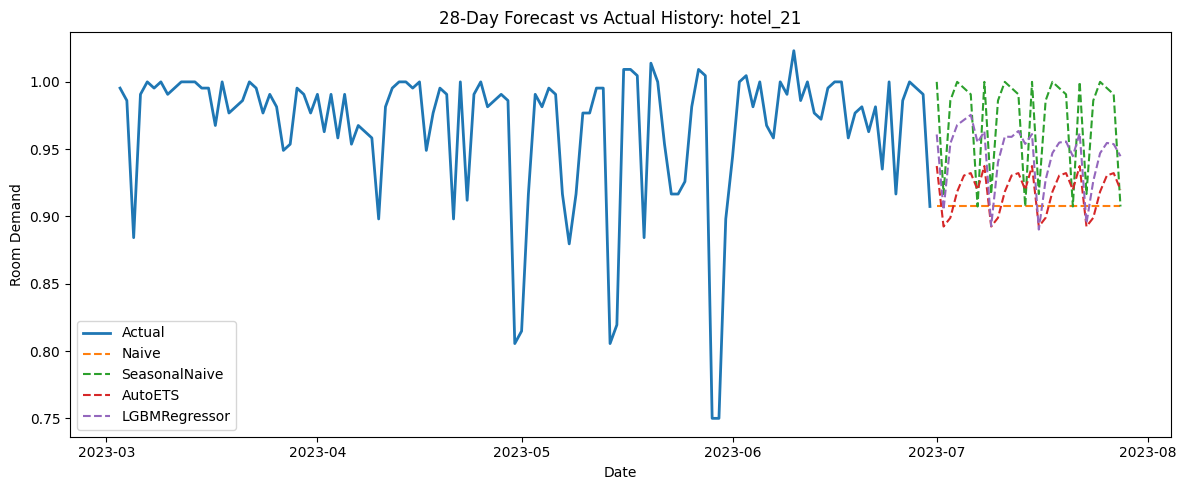

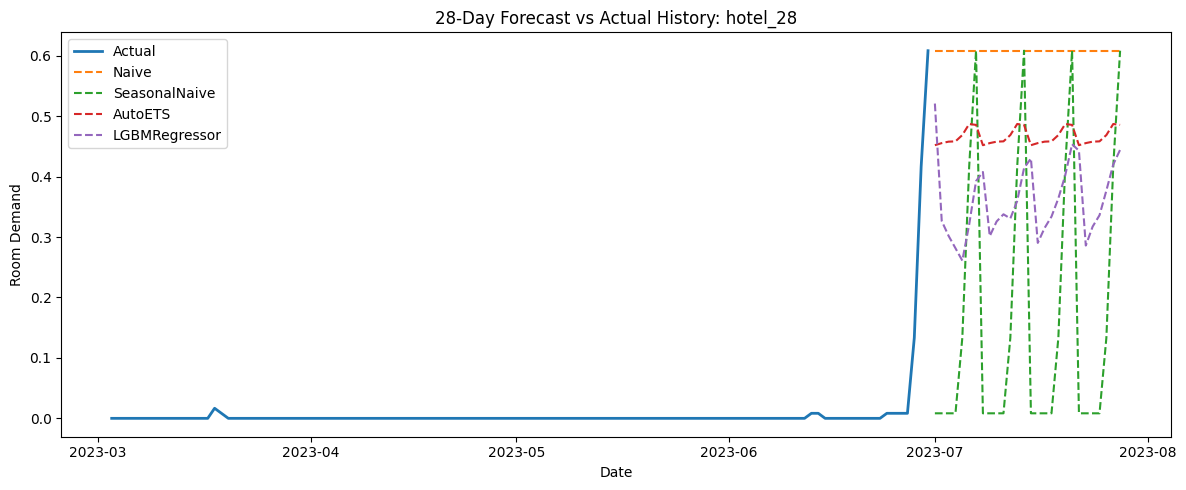

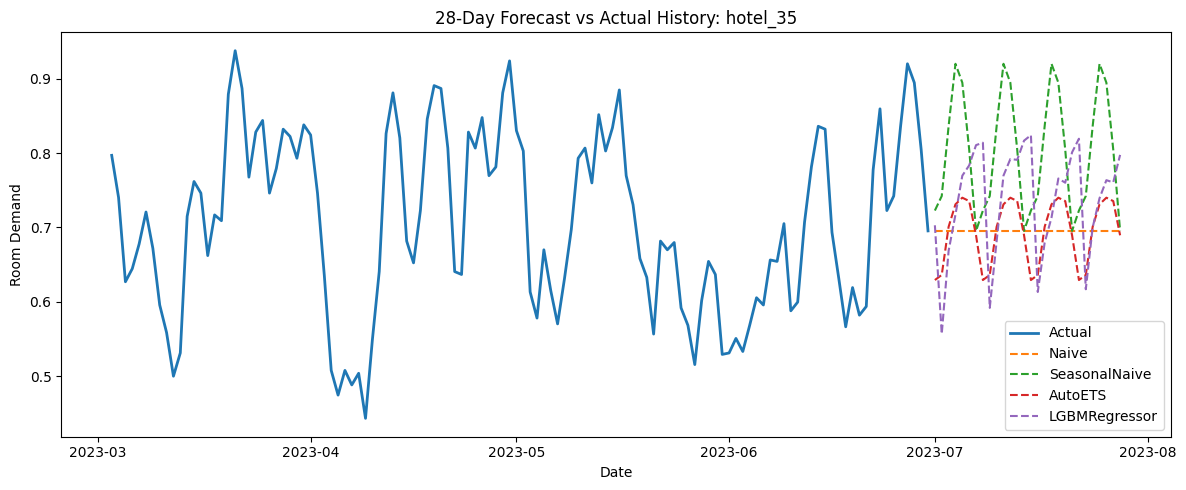

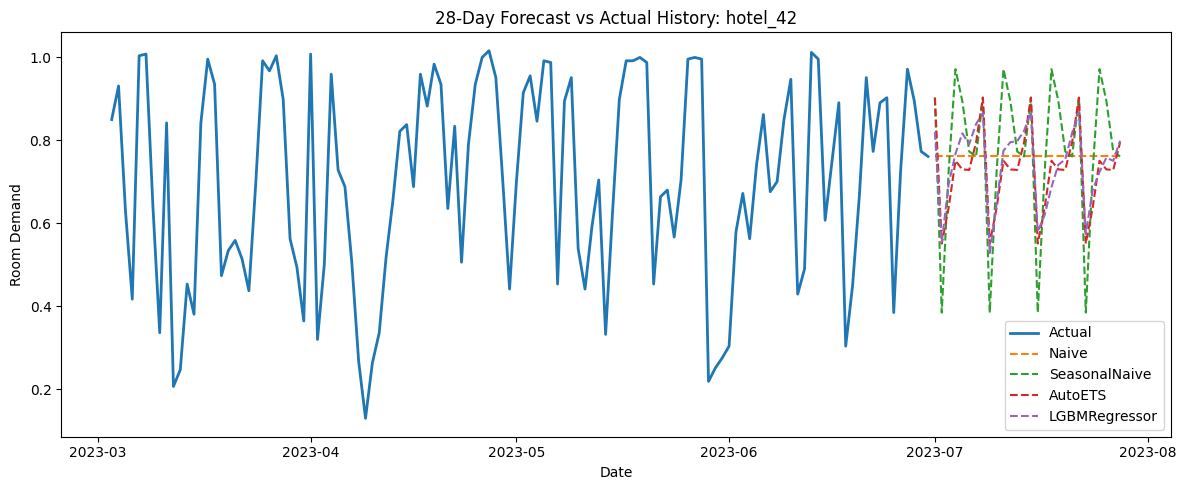

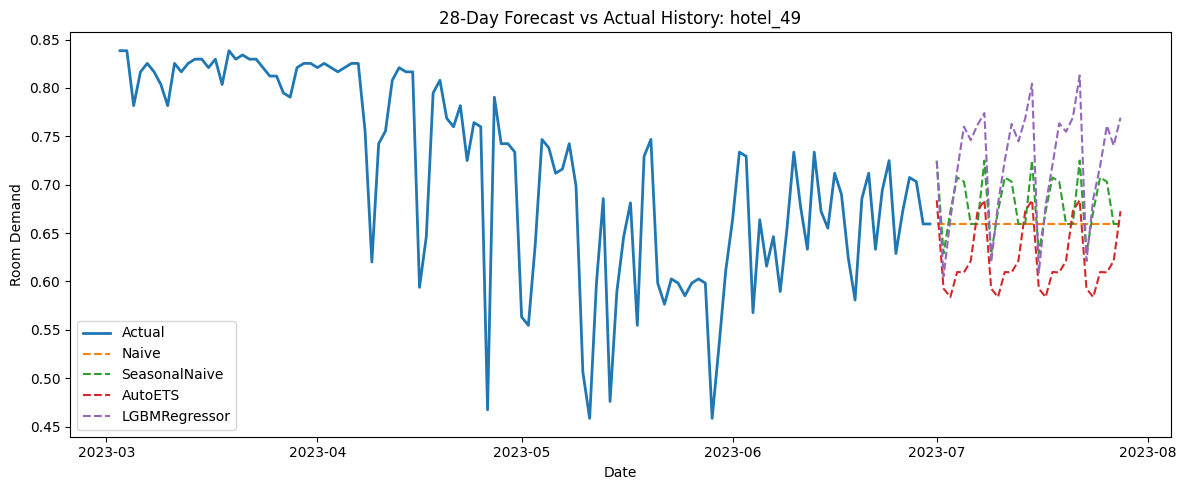

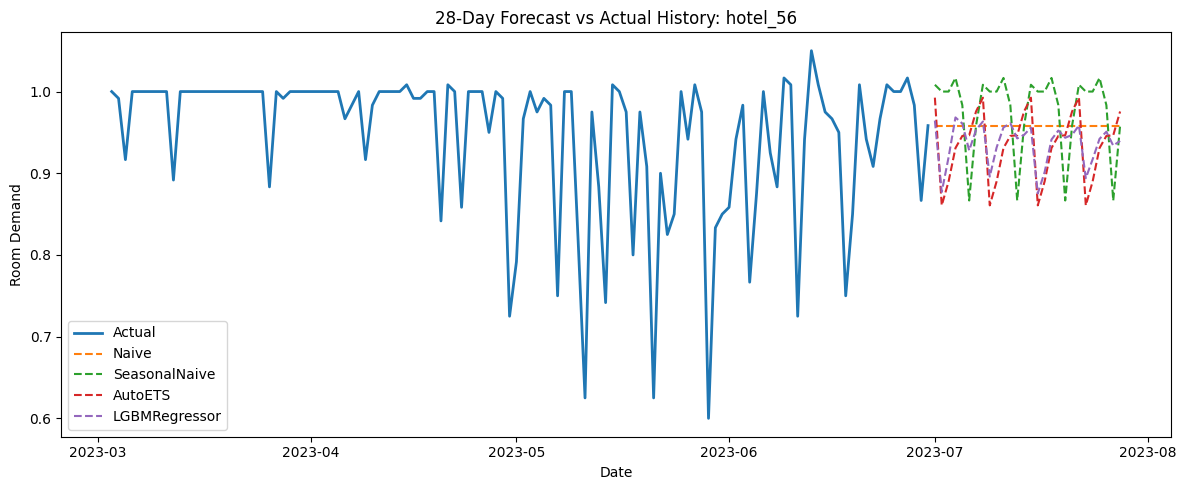

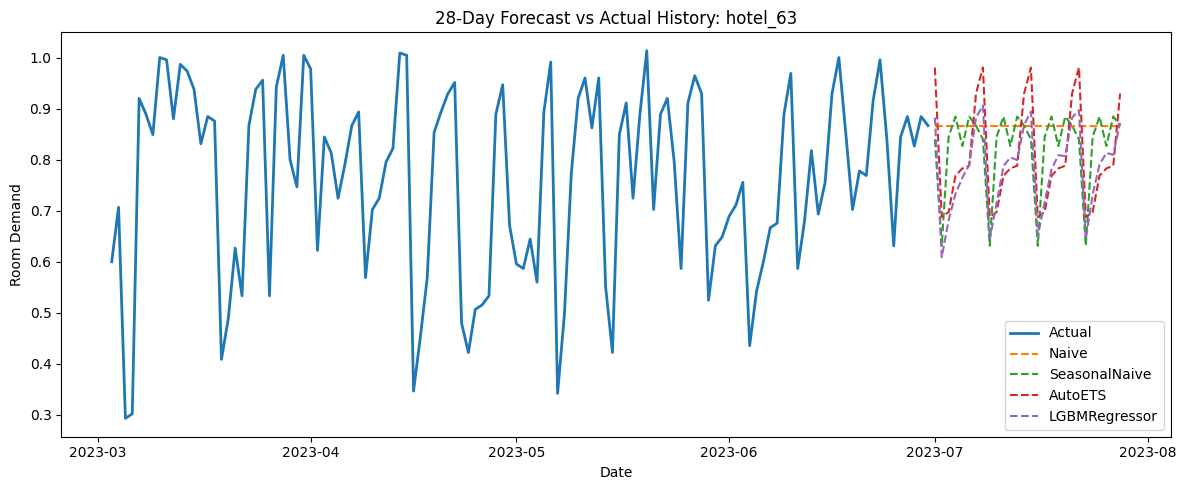

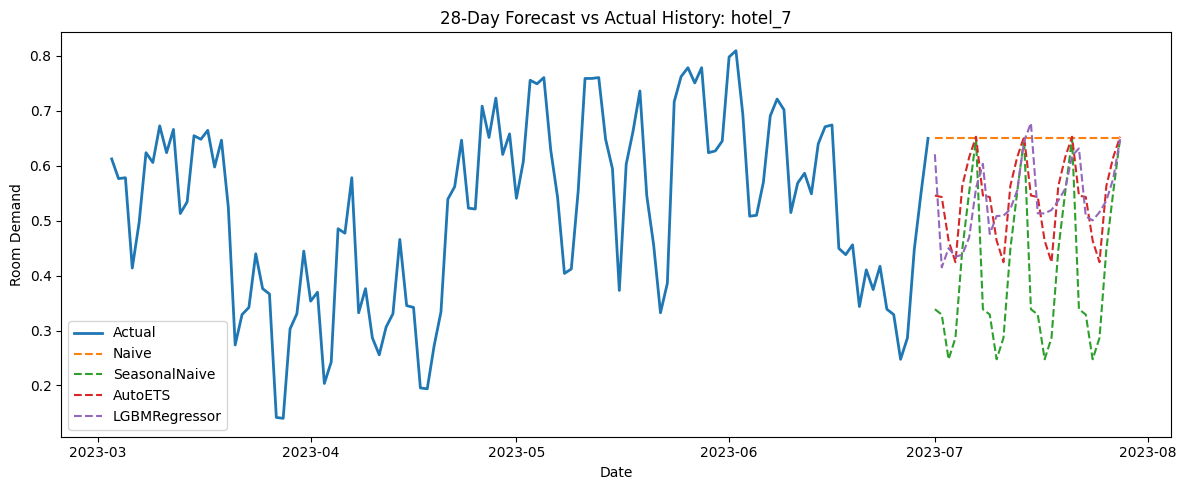

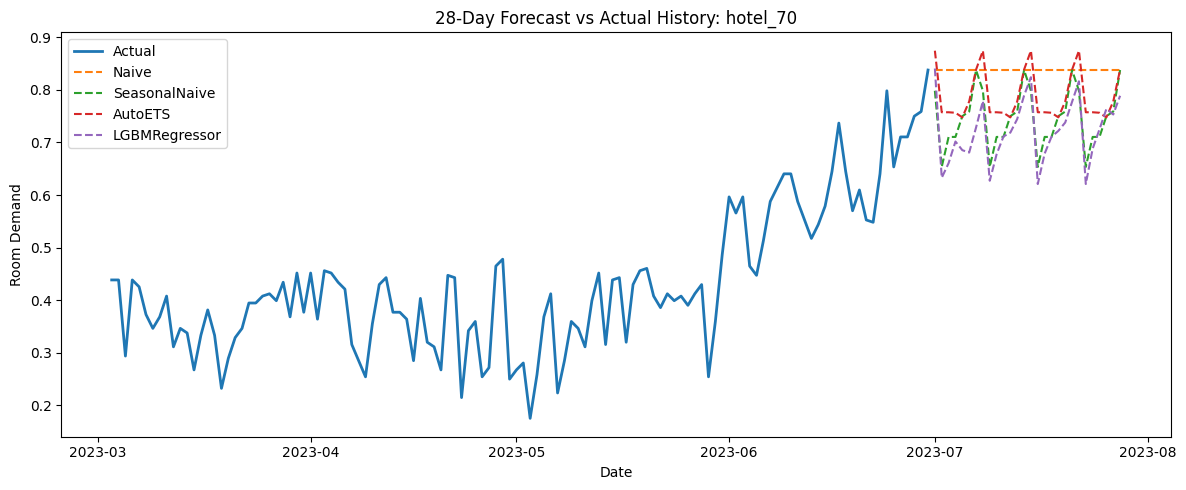

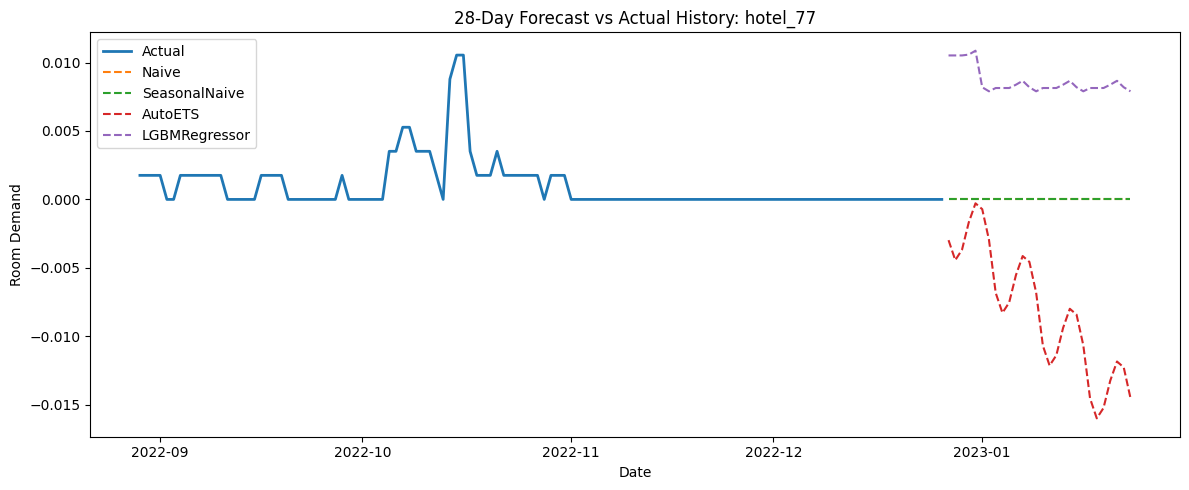

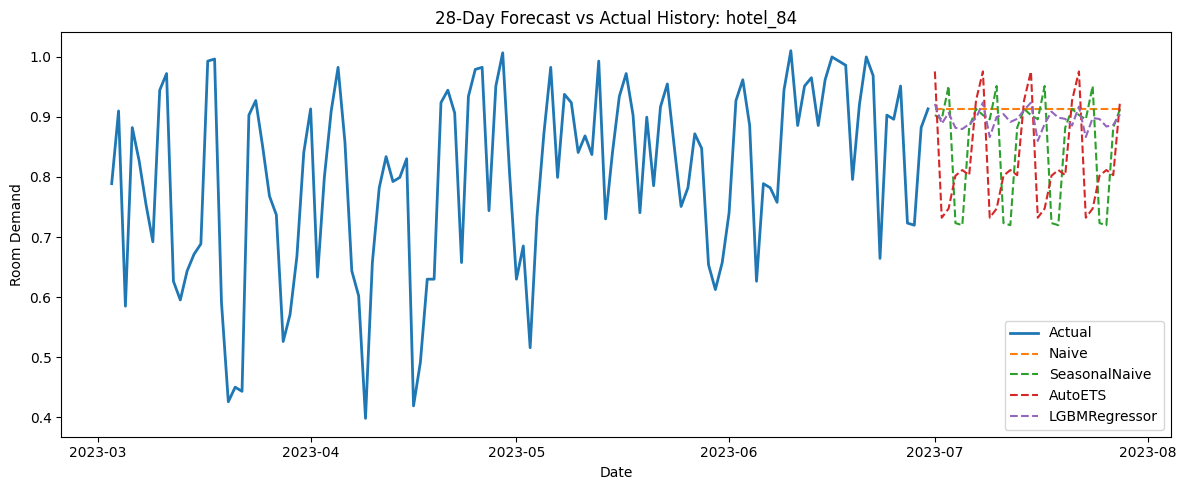

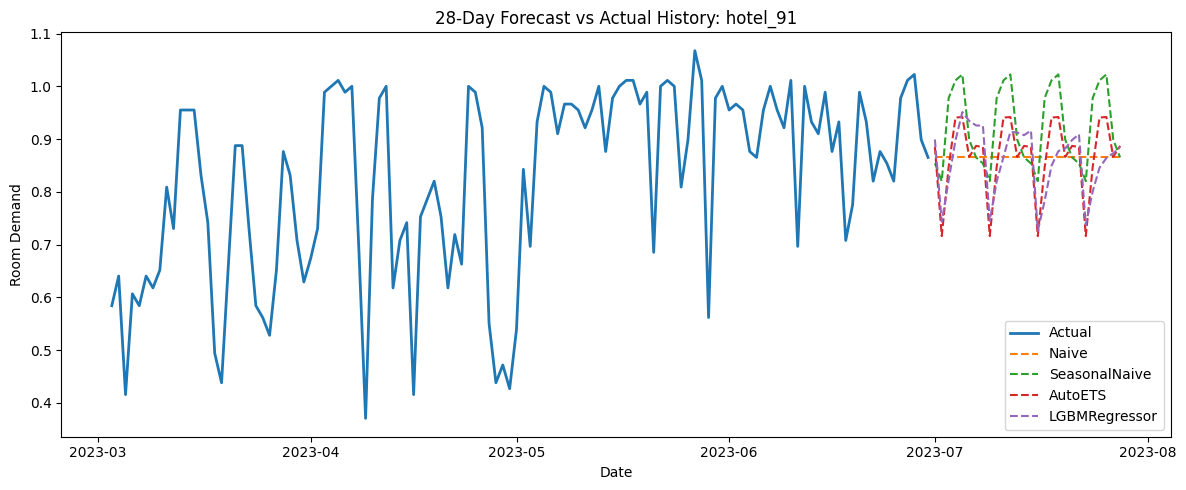

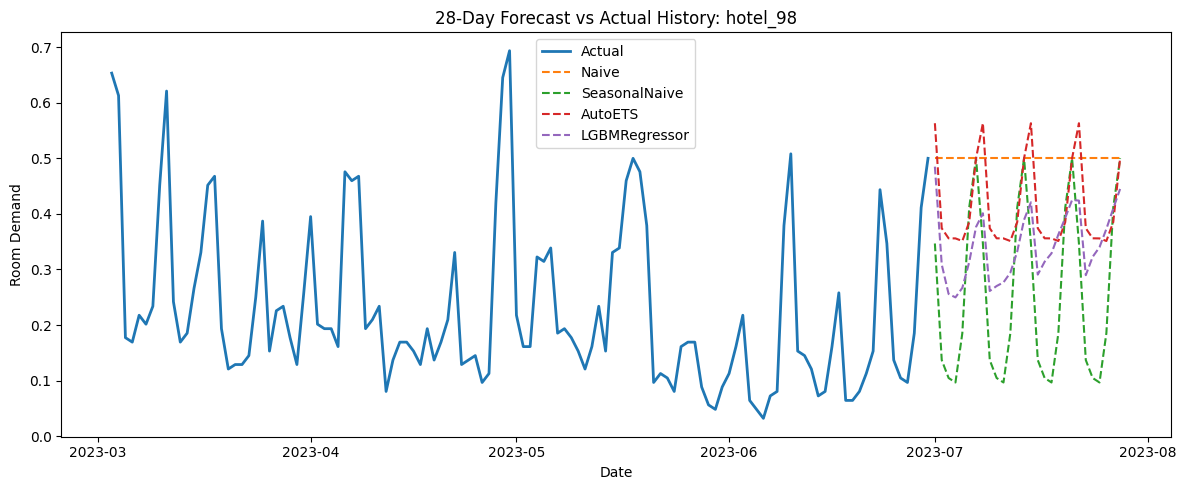

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

model_cols = [c for c in final_forecasts.columns if c not in ["unique_id", "ds"]]

for uid in df["unique_id"].unique():
    hist = df[df["unique_id"] == uid].tail(120)
    future = final_forecasts[final_forecasts["unique_id"] == uid]

    plt.figure(figsize=(12, 5))
    plt.plot(hist["ds"], hist["y"], label="Actual", linewidth=2)

    for model in model_cols:
        plt.plot(future["ds"], future[model], label=model, linestyle="--")

    plt.title(f"28-Day Forecast vs Actual History: {uid}")
    plt.xlabel("Date")
    plt.ylabel("Room Demand")
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"plots/{uid}_forecast.png", dpi=300)
    plt.show()

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNBEATS, AutoNHITS

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNBEATS, AutoNHITS

nbeats_config = {
    "input_size": 56,
    "max_steps": 50
}

nhits_config = {
    "input_size": 56,
    "max_steps": 50
}

nf = NeuralForecast(
    models=[
        AutoNBEATS(h=28, config=nbeats_config, num_samples=3),
        AutoNHITS(h=28, config=nhits_config, num_samples=3)
    ],
    freq="D"
)

In [ ]:
from timecopilot import Chronos

# Chronos is zero-shot, so it's very fast
chronos = Chronos(model_name="amazon/chronos-t5-tiny")
cv_chronos = chronos.cross_validation(df=df, h=28, n_windows=5, step_size=28)

In [ ]:
cv_nf = nf.cross_validation(
    df=df,
    h=28,
    n_windows=5,
    step_size=28
)

cv_nf.head()

2026-04-30 20:15:08,007	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-04-30 20:15:13,539	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-04-30_20-14-53   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 3                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-04-30_20-14-53
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-30_20-14-53_111761_2388/artifacts/2026-04-30_20-15-13/_train_tune_2026-04-30_20-14-53/driver_artifacts`


(_train_tune pid=15721) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=15721) Seed set to 1
(_train_tune pid=15721) /usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:599: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
(_train_tune pid=15721)   warnings.warn(
(_train_tune pid=15721) GPU available: False, used: False
(_train_tune pid=15721) TPU available: False, using: 0 TPU cores
(_train_tune pid=15721) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=15721) 2026-04-30 20:15:35.780913: I external/local_xla/xl

(_train_tune pid=15721) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=15721) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=15721) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=15721) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=15721) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=15721) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=15721) │ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
(_train_tune pid=15721) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=15721) Trainable params: 2.6 M                                                         
(_train_tune pid=15721) Non-trainable params: 4.8 K                                                     
(_train_tune pid=15721) Total params: 2.6 M                                                           

(_train_tune pid=15721) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(_train_tune pid=15721) `Trainer.fit` stopped: `max_steps=50` reached.


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

,unique_id,ds,cutoff,AutoNBEATS,AutoNHITS,y
0,hotel_0,2023-02-11,2023-02-10,0.750624,0.698222,0.827160
1,hotel_0,2023-02-12,2023-02-10,0.682464,0.623221,0.518519
2,hotel_0,2023-02-13,2023-02-10,0.631730,0.604603,0.629630
3,hotel_0,2023-02-14,2023-02-10,0.739488,0.616211,0.629630
4,hotel_0,2023-02-15,2023-02-10,0.728043,0.647113,0.888889


In [ ]:
cv_nf.head()
cv_nf.columns

Index(['unique_id', 'ds', 'cutoff', 'AutoNBEATS', 'AutoNHITS', 'y'], dtype='object')

In [ ]:
results = results.merge(
    cv_nf.drop(columns=["y"], errors="ignore"),
    on=["unique_id", "ds", "cutoff"],
    how="left"
)

results.to_csv("cross_validation_results.csv", index=False)

results.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,LGBMRegressor,AutoNBEATS,AutoNHITS
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.798058,0.851097,0.750624,0.698222
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.592257,0.645710,0.682464,0.623221
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.611757,0.758823,0.631730,0.604603
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.625062,0.818447,0.739488,0.616211
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.616607,0.823287,0.728043,0.647113


In [ ]:
print(cv_nf.head())
print(cv_nf.columns)

  unique_id         ds     cutoff  AutoNBEATS  AutoNHITS         y
0   hotel_0 2023-02-11 2023-02-10    0.750624   0.698222  0.827160
1   hotel_0 2023-02-12 2023-02-10    0.682464   0.623221  0.518519
2   hotel_0 2023-02-13 2023-02-10    0.631730   0.604603  0.629630
3   hotel_0 2023-02-14 2023-02-10    0.739488   0.616211  0.629630
4   hotel_0 2023-02-15 2023-02-10    0.728043   0.647113  0.888889
Index(['unique_id', 'ds', 'cutoff', 'AutoNBEATS', 'AutoNHITS', 'y'], dtype='object')


In [ ]:
results = results.merge(
    cv_nf.drop(columns=["y"], errors="ignore"),
    on=["unique_id", "ds", "cutoff"],
    how="left"
)

results.to_csv("cross_validation_results.csv", index=False)

In [ ]:
final_metrics
win_counts

,Model,Wins,Metric
0,LGBMRegressor,6,MAE
1,AutoETS,6,MAE
2,Naive,5,MAE
3,SeasonalNaive,2,MAE
4,LGBMRegressor,9,RMSE
5,AutoETS,7,RMSE
6,Naive,2,RMSE
7,SeasonalNaive,1,RMSE
8,LGBMRegressor,8,MAPE
9,AutoETS,4,MAPE


In [ ]:
final_metrics.to_csv("metric_summary_by_series_method.csv", index=False)
win_counts.to_csv("model_win_counts.csv", index=False)

In [ ]:
nf.fit(df)
nf_forecast = nf.predict()

final_forecasts = final_forecasts.merge(
    nf_forecast,
    on=["unique_id", "ds"],
    how="left"
)

final_forecasts.to_csv("final_test_forecasts.csv", index=False)

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-04-30_20-21-59   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 3                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-04-30_20-21-59
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-30_20-14-53_111761_2388/artifacts/2026-04-30_20-21-59/_train_tune_2026-04-30_20-21-59/driver_artifacts`


/usr/local/lib/python3.12/dist-packages/ray/tune/registry.py:280: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return pickle.loads(value)
/usr/local/lib/python3.12/dist-packages/ray/tune/registry.py:280: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return pickle.loads(value)
/usr/local/lib/python3.12/dist-packages/ray/tune/registry.py:280: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return pickle.loads(value)
/usr/local/lib/python3.12/dist-packages/ray/tune/registry.py:280: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return pickle.loads(value)
/usr/local/lib/python3.12/dist-packages/ray/tune/registry.py:280: FutureWarning: `isinstance

(raylet) Warning: The actor ImplicitFunc is very large (19 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.


(pid=17670) /usr/local/lib/python3.12/dist-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=17670)   actor_class = pickle.loads(pickled_class)
(pid=17670) /usr/local/lib/python3.12/dist-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=17670)   actor_class = pickle.loads(pickled_class)
(_train_tune pid=17670) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=17670) Seed set to 1
(_train_tune pid=17670) /usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:599: UserWarning: val_check_steps is

(_train_tune pid=17670) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=17670) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=17670) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=17670) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=17670) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=17670) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=17670) │ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
(_train_tune pid=17670) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=17670) Trainable params: 2.6 M                                                         
(_train_tune pid=17670) Non-trainable params: 4.8 K                                                     
(_train_tune pid=17670) Total params: 2.6 M                                                           

...

(_train_tune pid=17898) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(_train_tune pid=17898) `Trainer.fit` stopped: `max_steps=50` reached.


(_train_tune pid=17898) Epoch 49/-2 ━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000      
(_train_tune pid=17898)                                                               train_loss_step:  
(_train_tune pid=17898)                                                               0.112             
(_train_tune pid=17898)                                                               train_loss_epoch: 
(_train_tune pid=17898)                                                               0.112 valid_loss: 
(_train_tune pid=17898)                                                               0.087             


(pid=18120) /usr/local/lib/python3.12/dist-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=18120)   actor_class = pickle.loads(pickled_class)
(pid=18120) /usr/local/lib/python3.12/dist-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=18120)   actor_class = pickle.loads(pickled_class)
(_train_tune pid=18120) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=18120) Seed set to 1
(_train_tune pid=18120) /usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:599: UserWarning: val_check_steps is

(_train_tune pid=18120) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=18120) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=18120) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=18120) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=18120) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=18120) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=18120) │ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
(_train_tune pid=18120) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=18120) Trainable params: 2.6 M                                                         
(_train_tune pid=18120) Non-trainable params: 4.8 K                                                     
(_train_tune pid=18120) Total params: 2.6 M                                                           

(_train_tune pid=18120) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
